In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random

import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

In [2]:
# Shapefile for aggregation
scratch = '/glade/derecho/scratch/dcalhoun'
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'

In [3]:
def build_fc_files(scratch, start, end, freq, lead_times):
    """Build list of forecast files (path, init_time, lead_time) for the given date range."""
    dates = pd.date_range(start=start, end=end, freq=freq)
    fc_files = []
    for init_time in dates:
        for lead_time in lead_times:
            date_str = init_time.strftime("%Y%m%d%H%M")
            year = date_str[:4]
            month = date_str[4:6]
            day = date_str[6:8]
            hour = date_str[8:]
            fc_path = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/{hour}/{lead_time}/{year}/{month}/*{day}.nc')
            if fc_path:
                fc_files.append((fc_path[0], str(init_time), lead_time))
    return fc_files

In [4]:
def build_an_files(scratch, start, end, freq):
    """Build list of analysis files (path, time) for the given date range. No lead dimension."""
    dates = pd.date_range(start=start, end=end, freq=freq)
    an_files = []
    for time in dates:
        date_str = time.strftime("%Y%m%d")
        year = date_str[:4]
        month = date_str[4:6]
        an_path = glob.glob(scratch + f'/ecmwf/ifs/an/0.125/2t/{year}/{month}/*{date_str}.nc')
        if an_path:
            an_files.append((an_path[0], str(time)))
    return an_files

In [5]:
# Build our lists of forecast and analysis files
start, end, freq = '2020-01-01', '2024-01-01', '12h'
lead_times = [12, 24, 36]
fc_files = build_fc_files(scratch, start=start, end=end, freq=freq, lead_times=lead_times)
an_files = build_an_files(scratch, start=start, end=end, freq=freq)
n_files = len(fc_files)
print(f'fc_files: {n_files}, an_files: {len(an_files)}')

fc_files: 5846, an_files: 2923


In [6]:
# Pick random valid times and select aligned forecast + analysis
valid_from_fc = {pd.to_datetime(init) + pd.Timedelta(hours=lead): (path, init, lead) for path, init, lead in fc_files}
valid_from_an = {pd.to_datetime(t): (path, t) for path, t in an_files}
common_valid = sorted(set(valid_from_fc) & set(valid_from_an))
n_pick = min(4, len(common_valid))
picked_valid = sorted(random.sample(common_valid, n_pick))
fc_selected = [valid_from_fc[vt] for vt in picked_valid]
an_selected = [valid_from_an[vt] for vt in picked_valid]
for vt in picked_valid:
    fc_file = valid_from_fc[vt][0]
    an_file = valid_from_an[vt][0]
    fc_end = fc_file.split('/')[-1]
    an_end = an_file.split('/')[-1]
    print(f'{vt}: fc={fc_end} an={an_end}')

2020-02-28 00:00:00: fc=ifs_fc_2t_1200_12_20200227.nc an=ifs_an_2t_20200228.nc
2020-12-02 00:00:00: fc=ifs_fc_2t_1200_12_20201201.nc an=ifs_an_2t_20201202.nc
2022-05-03 12:00:00: fc=ifs_fc_2t_0000_12_20220503.nc an=ifs_an_2t_20220503.nc
2023-02-05 12:00:00: fc=ifs_fc_2t_0000_12_20230205.nc an=ifs_an_2t_20230205.nc


In [7]:
# Define our GeoAggregator with our shapefile and grid
# Calculates a weightmap of overlaps between grid boxes and polygons
geo_agg = wxagg.GeoAggregator(shapefile_path=shapefile_path, grid_path=fc_selected[0][0])

In [8]:
geo_agg

GeoAggregator
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [9]:
# Build our ForecastAggregator and AnalysisAggregator
# from our forecast and analysis files
# We use the weightmap we already calculated
fc_agg = wxagg.ForecastAggregator.from_GeoAggregator(geo_agg, forecast_files=fc_selected, var_name="t2m")
an_agg = wxagg.AnalysisAggregator.from_GeoAggregator(geo_agg, analysis_files=an_selected, var_name="t2m")

In [10]:
fc_agg

ForecastAggregator
n_files: 4
init_times:
	2020-02-27 12:00:00
	2020-12-01 12:00:00
	2022-05-03 00:00:00
	2023-02-05 00:00:00
lead_times: [12]
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [11]:
an_agg

AnalysisAggregator
n_files: 4
times:
	2020-02-28 00:00:00
	2020-12-02 00:00:00
	2022-05-03 12:00:00
	2023-02-05 12:00:00
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [12]:
# Run the aggregation to build a data table of our forecast data
df_fc = fc_agg.build_data_table()

In [13]:
# Same for analysis
df_an = an_agg.build_data_table()

In [14]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2020-02-28 00:00:00,2020-02-27 12:00:00,12,278.793434
1,01003,2020-02-28 00:00:00,2020-02-27 12:00:00,12,280.731039
2,01005,2020-02-28 00:00:00,2020-02-27 12:00:00,12,279.062697
3,01007,2020-02-28 00:00:00,2020-02-27 12:00:00,12,278.710049
4,01009,2020-02-28 00:00:00,2020-02-27 12:00:00,12,277.492739
...,...,...,...,...,...
12431,56037,2023-02-05 12:00:00,2023-02-05 00:00:00,12,263.817634
12432,56039,2023-02-05 12:00:00,2023-02-05 00:00:00,12,265.040003
12433,56041,2023-02-05 12:00:00,2023-02-05 00:00:00,12,264.656020
12434,56043,2023-02-05 12:00:00,2023-02-05 00:00:00,12,267.947718


In [15]:
df_an

,geo_id,time,t2m
0,01001,2020-02-28 00:00:00,280.959169
1,01003,2020-02-28 00:00:00,282.152374
2,01005,2020-02-28 00:00:00,281.317100
3,01007,2020-02-28 00:00:00,281.235328
4,01009,2020-02-28 00:00:00,280.344420
...,...,...,...
12431,56037,2023-02-05 12:00:00,264.076087
12432,56039,2023-02-05 12:00:00,264.567180
12433,56041,2023-02-05 12:00:00,264.887857
12434,56043,2023-02-05 12:00:00,268.408058


In [16]:
# Save our aggregated features
fc_agg.save_data_table("test_fc.csv")
an_agg.save_data_table("test_an.csv")

In [17]:
# Create table with bias (forecast - analysis) and abs_error
var = 't2m'
df_error = pd.merge(
    df_fc, df_an,
    left_on=['geo_id', 'valid_time'], right_on=['geo_id', 'time'],
    suffixes=('_fc', '_an'), how='inner'
)
df_error['bias'] = df_error[f'{var}_fc'] - df_error[f'{var}_an']
df_error['abs_error'] = df_error['bias'].abs()
df_error = df_error[['geo_id', 'valid_time', 'init_time', 'lead_time', f'{var}_fc', f'{var}_an', 'bias', 'abs_error']]
df_error

,geo_id,valid_time,init_time,lead_time,t2m_fc,t2m_an,bias,abs_error
0,01001,2020-02-28 00:00:00,2020-02-27 12:00:00,12,278.793434,280.959169,-2.165735,2.165735
1,01003,2020-02-28 00:00:00,2020-02-27 12:00:00,12,280.731039,282.152374,-1.421335,1.421335
2,01005,2020-02-28 00:00:00,2020-02-27 12:00:00,12,279.062697,281.317100,-2.254403,2.254403
3,01007,2020-02-28 00:00:00,2020-02-27 12:00:00,12,278.710049,281.235328,-2.525279,2.525279
4,01009,2020-02-28 00:00:00,2020-02-27 12:00:00,12,277.492739,280.344420,-2.851681,2.851681
...,...,...,...,...,...,...,...,...
12431,56037,2023-02-05 12:00:00,2023-02-05 00:00:00,12,263.817634,264.076087,-0.258453,0.258453
12432,56039,2023-02-05 12:00:00,2023-02-05 00:00:00,12,265.040003,264.567180,0.472823,0.472823
12433,56041,2023-02-05 12:00:00,2023-02-05 00:00:00,12,264.656020,264.887857,-0.231837,0.231837
12434,56043,2023-02-05 12:00:00,2023-02-05 00:00:00,12,267.947718,268.408058,-0.460339,0.460339


In [18]:
# Statistics by valid time
df_error.groupby('valid_time').bias.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2020-02-28 00:00:00,3109.0,-1.526681,1.141225,-5.460668,-2.213088,-1.446076,-0.651706,2.176117
2020-12-02 00:00:00,3109.0,-1.115859,1.253933,-5.457922,-1.861009,-0.797734,-0.257709,1.918598
2022-05-03 12:00:00,3109.0,-0.128004,0.955519,-3.751379,-0.708072,-0.220455,0.351015,4.394672
2023-02-05 12:00:00,3109.0,-0.193766,1.029099,-2.749941,-0.964045,-0.282138,0.494936,3.040403


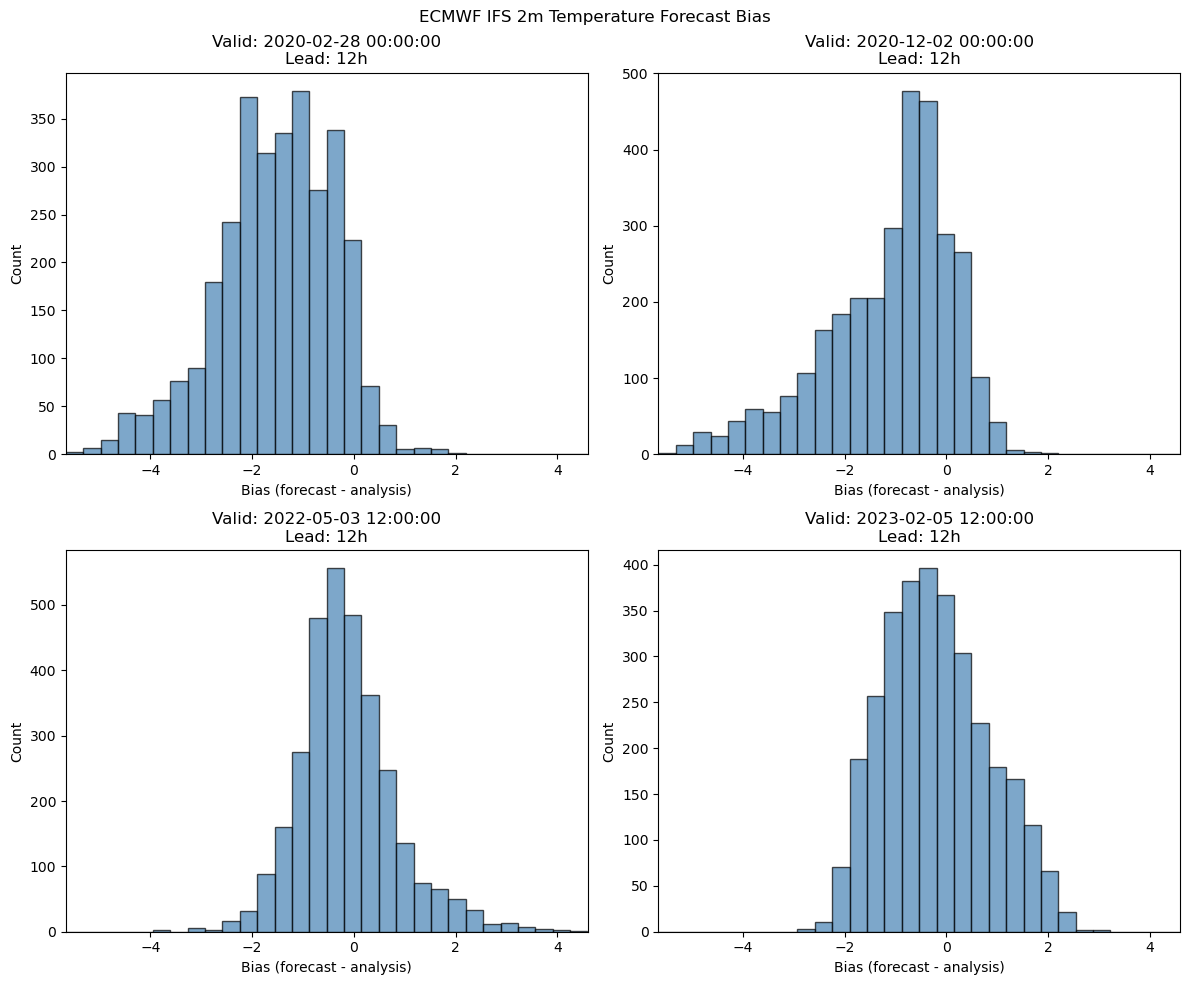

In [19]:
# Plot forecast bias histograms by valid time
valid_times = sorted(df_error['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
bins = 30

bias_min = df_error['bias'].min()
bias_max = df_error['bias'].max()
padding = 0.02 * (bias_max - bias_min) if bias_max != bias_min else 0.1
bmin_pad = bias_min - padding
bmax_pad = bias_max + padding

bin_edges = np.linspace(bmin_pad, bmax_pad, bins + 1)

for ax, vt in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == vt]
    ax.hist(sub['bias'], bins=bin_edges, color='steelblue', edgecolor='k', alpha=0.7)
    ax.set_title(f'Valid: {vt}\nLead: {sub["lead_time"].iloc[0]}h')
    ax.set_xlabel('Bias (forecast - analysis)')
    ax.set_ylabel('Count')
    ax.set_xlim([bmin_pad, bmax_pad])

plt.suptitle('ECMWF IFS 2m Temperature Forecast Bias')
plt.tight_layout()
plt.show()

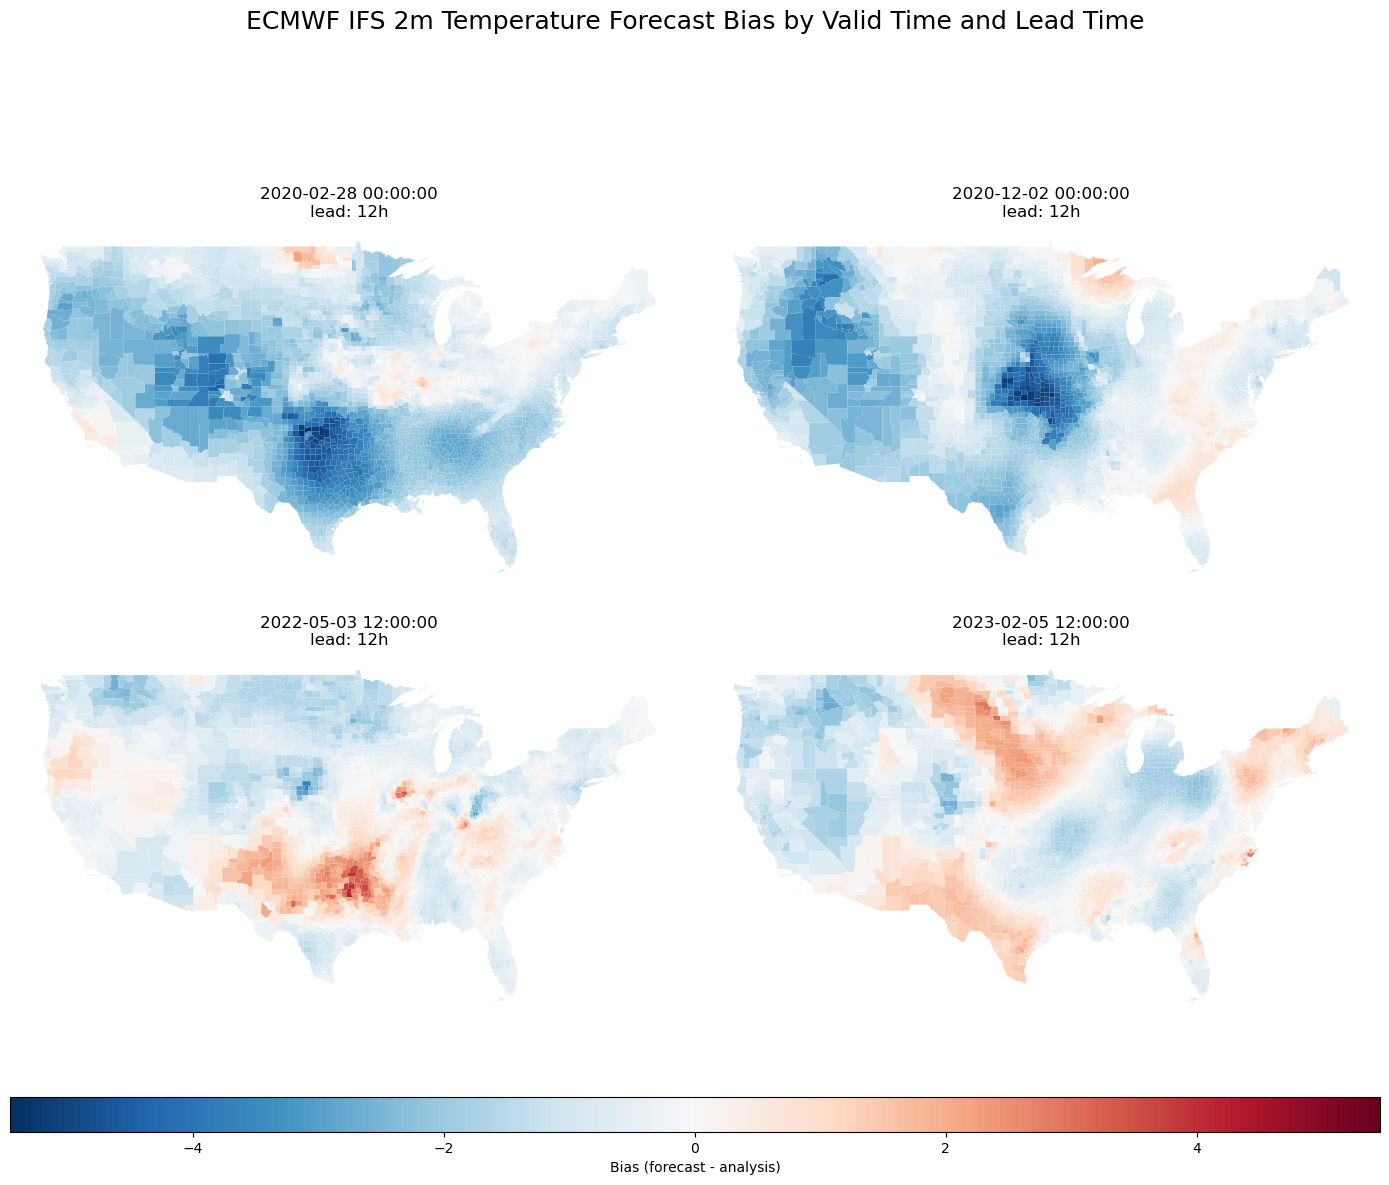

In [20]:
# Plot bias maps by valid time
fc_agg.shapefile.rename(columns={'GEOID': 'geo_id'}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

bias_max = np.abs(df_error['bias']).max()
vmin, vmax = -bias_max, bias_max
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdBu_r'

valid_times = sorted(df_error['valid_time'].unique())
for ax, valid_time in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == valid_time]
    gdf_plot = fc_agg.shapefile.merge(sub[['geo_id', 'bias']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='bias', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecast Bias by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='Bias (forecast - analysis)'
)
plt.show()

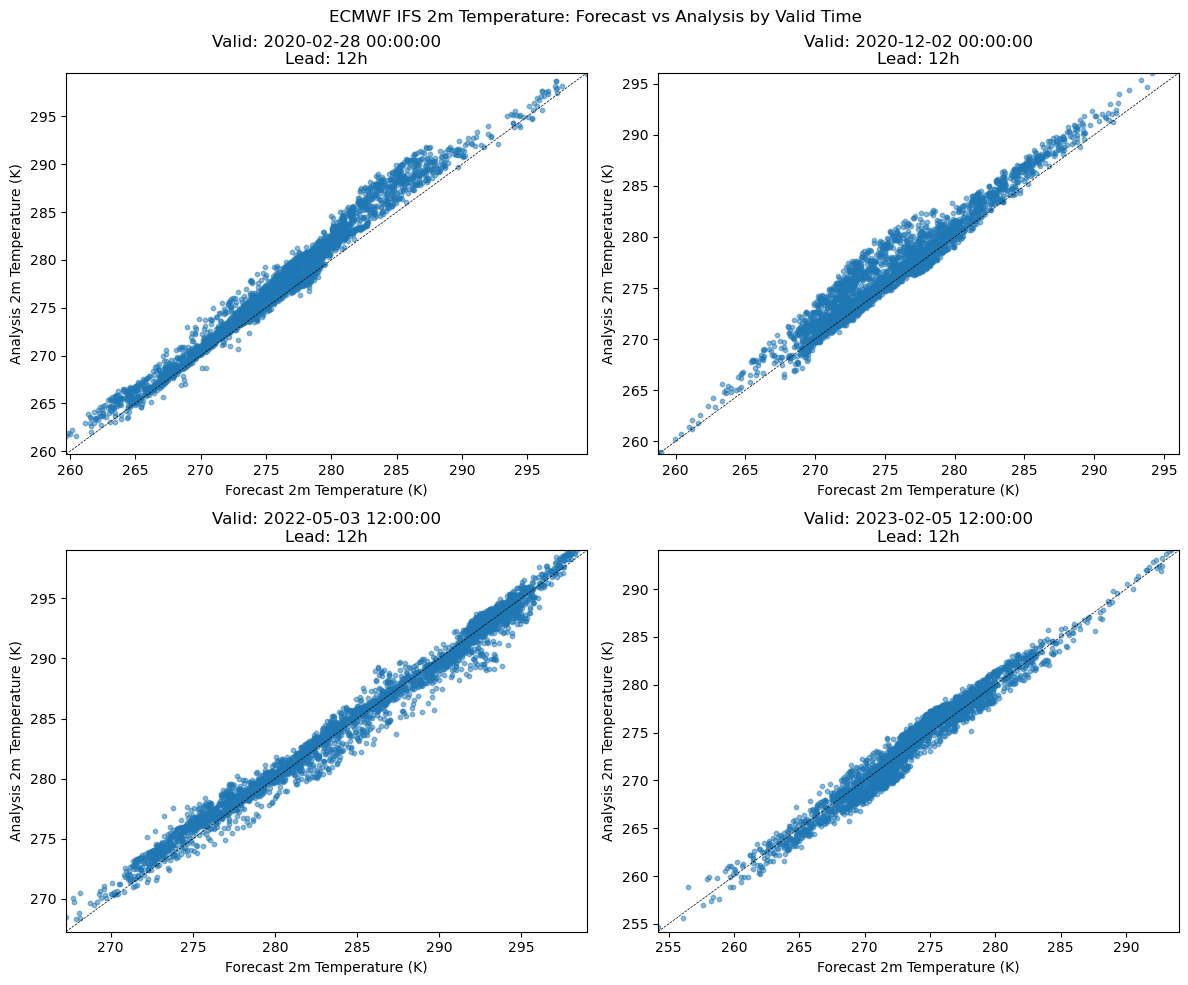

In [24]:
# Scatter plot: forecast vs analysis temperature by valid time
valid_times = sorted(df_error['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, vt in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == vt]
    ax.scatter(sub['t2m_fc'], sub['t2m_an'], alpha=0.5, s=10)
    lims = [sub[['t2m_fc', 't2m_an']].min().min(), sub[['t2m_fc', 't2m_an']].max().max()]
    ax.plot(lims, lims, 'k--', linewidth=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Forecast 2m Temperature (K)')
    ax.set_ylabel('Analysis 2m Temperature (K)')
    ax.set_title(f'Valid: {vt}\nLead: {sub["lead_time"].iloc[0]}h')

plt.suptitle('ECMWF IFS 2m Temperature: Forecast vs Analysis by Valid Time')
plt.tight_layout()
plt.show()